In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime, timedelta
import numpy as np
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
unique_devices = ['Sensor_presence', 'Plug_fan', 'Light_bulb', 'Plug_pc']

In [3]:
def remove_message_timestamp(message):
    regex = r"'time': \d+, "
    new_message = re.sub(regex, '', str(message))
    regex = r"'dpId': \d+, "
    new_message = re.sub(regex, '', str(new_message))
    return eval(new_message)

def remove_invalid_codes(message):
    valid_codes = ['switch_led', 'switch_1', 'presence_state', 'doorcontact_state']
    result = []
    for state in message:
        if state['code'] in valid_codes:
            result.append(state)
    if len(result) > 0:
        return result
    else:
        return np.nan

def time_interval(dt, minutes=60):
    total_seconds = timedelta(hours=dt.hour, minutes=dt.minute, seconds=dt.second).total_seconds()
    interval = total_seconds // (minutes * 60)
    return int(interval)

def device_change_heatmap_1(df):
    df['interval'] = df['timeStamp'].apply(time_interval)
    routine_dict = pd.DataFrame({'interval': range(24)})
    for device in unique_devices:
        a = df[df['devId'] == device].groupby('interval')['devId'].count().to_frame().rename({'devId': device}, axis=1)
        routine_dict = routine_dict.merge(a, on='interval', how='left')

    routine_dict = routine_dict.drop('interval', axis=1)
    routine_map = routine_dict.fillna(0).T
    fig = plt.figure(figsize=(25, 5))
    
    heatmap = sns.heatmap(routine_map, vmin=-1, vmax=24, annot=True, cmap='Blues', fmt='.0f',
                          linecolor='black', annot_kws={'size': 16, 'weight': 'heavy'})
    heatmap.collections[0].colorbar.ax.tick_params(labelsize=22)
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22, rotation=0)
    plt.xlabel('Time of day', fontsize=22)
    return fig

def device_change_heatmap_Teste(df, unique_devices):
    df_meio_semana = df.query('day_week != "Sunday" and day_week != "Saturday"')
    df_fim_semana = df.query('day_week == "Sunday" or day_week == "Saturday"')

    df_meio_semana['interval'] = df_meio_semana['timeStamp'].apply(time_interval)
    df_fim_semana['interval'] = df_fim_semana['timeStamp'].apply(time_interval)
    routine_meio_semana = pd.DataFrame({'interval': range(24)})
    routine_fim_semana = pd.DataFrame({'interval': range(24)})

    for device in unique_devices:
        a = df_meio_semana[df_meio_semana['devId'] == device].groupby('interval')['devId'].count().to_frame().rename({'devId': device}, axis=1)
        b = df_fim_semana[df_fim_semana['devId'] == device].groupby('interval')['devId'].count().to_frame().rename({'devId': device}, axis=1)

        routine_meio_semana = routine_meio_semana.merge(a, on='interval', how='left')
        routine_fim_semana = routine_fim_semana.merge(b, on='interval', how='left')

    routine_meio_semana = routine_meio_semana.drop('interval', axis=1)
    routine_meio_semana = routine_meio_semana.fillna(0).T

    routine_fim_semana = routine_fim_semana.drop('interval', axis=1)
    routine_fim_semana = routine_fim_semana.fillna(0).T

    fig, axes = plt.subplots(2, 1, figsize=(25, 5))
    heatmap = sns.heatmap(routine_meio_semana, ax=axes[0], vmin=-1, vmax=24, annot=True, cmap='Greens', fmt='.0f',
                          linecolor='black', annot_kws={'size': 16, 'weight': 'heavy'})
    heatmap.collections[0].colorbar.ax.tick_params(labelsize=22)
    
    axes[0].set_title('Weekdays', fontsize=30)
    axes[0].set_xlabel('Time of day', fontsize=20)
    axes[0].tick_params(axis='both', labelsize=20)
    
    heatmap = sns.heatmap(routine_fim_semana, ax=axes[1], vmin=-1, vmax=24, annot=True, cmap='Greens', fmt='.0f',
                          linecolor='black', annot_kws={'size': 16, 'weight': 'heavy'})
    heatmap.collections[0].colorbar.ax.tick_params(labelsize=22)
    axes[1].set_title('Weekend', fontsize=30)
    axes[1].set_xlabel('Time of day', fontsize=20)
    axes[1].tick_params(axis='both', labelsize=20)

    plt.subplots_adjust(wspace=0.7, hspace=1)
    return fig

In [4]:
def trata_dados_reais(caminho:str):
    message_list = []
    hour_list = []
    with open(caminho, "r") as json:
        data = json.read()
        for line in data.split('\n')[1:-1]:
            hour_list.append(eval(line)['hora'])
            dict_msg = eval(eval(line)['mensagem'].replace('true', 'True').replace('false', 'False'))['bizData']
            message_list.append(dict_msg)
        json.close()
    
    df = pd.DataFrame(message_list).rename(columns={'properties': 'message'})
    df['timeStamp'] = hour_list
    df['message'] = df['message'].astype(str)
    
    dicionario = {
        'ebfe6c248a7dfe6910qdcb': 'Plug_fan',
        'eb061b979815289561tyqf': 'Sensor_presence',
        'eb31770a1d7812125degzr': 'Light_bulb',
        'eb176a71685a57c19arlbp': 'abertura',
        'ebcc9b86347718a3808ezt': 'Plug_pc',
        'ebf1d890916d1a73b4vtnv': 'temp_humidade'
    }
    
    df['devId'] = df['devId'].apply(lambda x: dicionario[x])
    
    df['message'] = df['message'].apply(remove_message_timestamp)
    df['message'] = df['message'].apply(remove_invalid_codes)
    df['timeStamp'] = df['timeStamp'].apply(lambda string: datetime.strptime(string, '%Y-%m-%dT%H:%M:%S.%f'))
    
    df = df[df['message'].notna()].reset_index(drop=True)
    df["day_week"] = df["timeStamp"].dt.day_name()
    
    unique_devices = ['Sensor_presence', 'Plug_fan', 'Light_bulb', 'Plug_pc']
    
    for device in unique_devices:
        result = (df[df['devId'] == device]['message'].shift(1) == df[df['devId'] == device]['message']).sum()
        print(f'{device}: {result}')
    
    remove_index = []
    for device in unique_devices:
        result = df[df['devId'] == device][(df[df['devId'] == device]['message'].shift(1) == df[df['devId'] == device]['message']).values].index.tolist()
        if len(result) > 0:
            remove_index.extend(result)
    df = df.drop(remove_index)
    return df

In [5]:
def trata_dados_gerados(caminho:str):
    df_gerado = pd.read_csv(caminho)
    colunas = ['devId', 'productKey', 'message', 'timeStamp']
    
    dicionario = {
        'QUARTO_PLUG_02-004': 'Plug_fan',
        'QUARTO_SENSOR_PRESENCA-002': 'Sensor_presence',
        'QUARTO_LAMPADA-001': 'Light_bulb',
        'QUARTO_PLUG_01-003': 'Plug_pc'
    }
    
    df_gerado['devId'] = df_gerado['device'].apply(lambda x: dicionario[x])
    df_gerado = df_gerado[colunas]
    
    df_gerado['timeStamp'] = df_gerado['timeStamp'].apply(lambda string: datetime.strptime(string, '%Y-%m-%d %H:%M:%S.%f'))
    df_gerado["day_week"] = df_gerado["timeStamp"].dt.day_name()
    
    return df_gerado

In [6]:
def time_interval_teste(dt, minutes=60):
    total_seconds = timedelta(hours=dt.hour, minutes=dt.minute, seconds=dt.second).total_seconds()
    interval = total_seconds // (minutes * 60)
    return int(interval)

def time_day_teste(dt):
    return pd.Timestamp(dt.year, dt.month, dt.day, dt.hour)

def monta_dataframe_por_dia(dados: pd.DataFrame):
    dados['day'] = dados['timeStamp'].apply(time_day_teste)

    routine = pd.DataFrame({'day': pd.date_range(start=dados['day'][0], end=dados.iloc[-1]['day'], freq='h')})
    for device in unique_devices:
        b = dados[dados['devId'] == device].groupby('day')['devId'].count().to_frame().rename({'devId': device}, axis=1)
        routine = routine.merge(b, on='day', how='left')

    # routine = routine.drop('interval', axis=1)
    routine = routine.fillna(0).T
    return routine

def gefico_linha(lista_df):
    grupo_processado = []
    for g in lista_df:    
        grupo = monta_dataframe_por_dia(g).T
        grupo['interval'] = grupo['day'].apply(time_interval_teste)
        grupo = grupo.astype({'Sensor_presence':'int', 'Plug_fan':'int', 'Light_bulb':'int', 'Plug_pc':'int'})
        grupo.drop(['day'], axis=1, inplace=True)
        grupo_processado.append(grupo.groupby(['interval']).mean())

    fig, axs = plt.subplots(2, 2, figsize=(12, 5), sharey=False)

    axs[0, 0].set_title('Sensor_presence', weight='bold')
    axs[0, 0].step(grupo_processado[0].index, grupo_processado[0]['Sensor_presence'], label='real', color='orange')
    # axs[0, 0].step(grupo_processado[1].index, grupo_processado[1]['Sensor_presence'], where='mid', label='generated_14_days', color='green')
    # axs[0, 0].step(grupo_processado[2].index, grupo_processado[2]['Sensor_presence'], where='mid', label='generated_30_days', color='Purple')
    axs[0, 0].step(grupo_processado[3].index, grupo_processado[3]['Sensor_presence'], where='mid', label='generated_60_days', color='blue')
    axs[0, 0].set_xlabel('hour of day')
    axs[0, 0].set_ylabel('status changing')
    
    axs[0, 1].set_title('Plug_fan', weight='bold')
    axs[0, 1].step(grupo_processado[0].index, grupo_processado[0]['Plug_fan'], color='orange')
    # axs[0, 1].step(grupo_processado[1].index, grupo_processado[1]['Plug_fan'], where='mid', color='green')
    # axs[0, 1].step(grupo_processado[2].index, grupo_processado[2]['Plug_fan'], where='mid', color='Purple')
    axs[0, 1].step(grupo_processado[3].index, grupo_processado[3]['Plug_fan'], where='mid', color='blue')
    axs[0, 1].set_xlabel('hour of day')
    axs[0, 1].set_ylabel('status changing')
    
    axs[1, 0].set_title('Light_bulb', weight='bold')
    axs[1, 0].step(grupo_processado[0].index, grupo_processado[0]['Light_bulb'], color='orange')
    # axs[1, 0].step(grupo_processado[1].index, grupo_processado[1]['Light_bulb'], where='mid', color='green')
    # axs[1, 0].step(grupo_processado[2].index, grupo_processado[2]['Light_bulb'], where='mid', color='Purple')
    axs[1, 0].step(grupo_processado[3].index, grupo_processado[3]['Light_bulb'], where='mid', color='blue')
    axs[1, 0].set_xlabel('hour of day')
    axs[1, 0].set_ylabel('status changing')
    
    axs[1, 1].set_title('Plug_pc', weight='bold')
    axs[1, 1].step(grupo_processado[0].index, grupo_processado[0]['Plug_pc'], color='orange')
    # axs[1, 1].step(grupo_processado[1].index, grupo_processado[1]['Plug_pc'], where='mid', color='green')
    # axs[0, 1].step(grupo_processado[2].index, grupo_processado[2]['Plug_pc'], where='mid', color='Purple')
    axs[1, 1].step(grupo_processado[3].index, grupo_processado[3]['Plug_pc'], where='mid', color='blue')
    axs[1, 1].set_xlabel('hour of day')
    axs[1, 1].set_ylabel('status changing')
    
    # plt.grid(axis='x', color='0.95')
    fig.legend(title='Legend:', loc='lower center', bbox_to_anchor=(0.5, -0.08), fancybox=False, shadow=False, borderpad=0.5, ncol=10)
    fig.suptitle('Device Behavior')
    plt.subplots_adjust(wspace=0.3, hspace=0.5)
    plt.show()
    return fig
        

# Graficos

In [10]:
df_real = trata_dados_reais('./dados_reais_14_dias.json')
df_gerado_14d = trata_dados_gerados('../dados/original/completo/dados_sintetico_validacao_14_dias.csv')
# df_gerado_30d = trata_dados_gerados('../dados/original/completo/dados-validacao-30-dias.csv')
df_gerado_60d = trata_dados_gerados('../dados/original/completo/dados_sintetico_validacao_60_dias.csv')

Sensor_presence: 1044
Plug_fan: 0
Light_bulb: 5
Plug_pc: 0


In [13]:
df_real.to_csv('df_real.csv', index=False)

IndexError: list index out of range

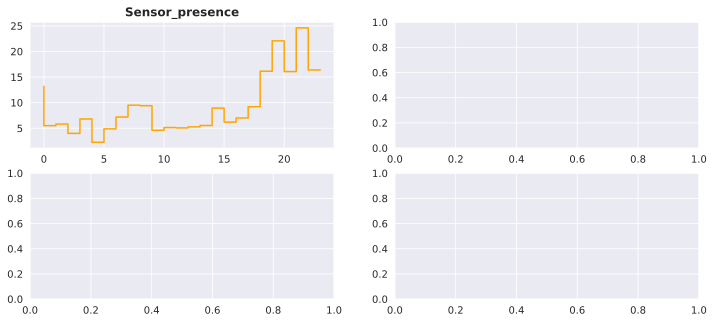

In [11]:
# Grafico de linha com comportamento dos dispositivos

grafico_comportamento = gefico_linha([df_real, df_gerado_14d, df_gerado_30d, df_gerado_60d])
grafico_comportamento.savefig("grafio_comportamento_real_gerado_60_dias.pdf", bbox_inches='tight')

/tmp/ipykernel_98178/3128356377.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_meio_semana['interval'] = df_meio_semana['timeStamp'].apply(time_interval)
/tmp/ipykernel_98178/3128356377.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fim_semana['interval'] = df_fim_semana['timeStamp'].apply(time_interval)
/tmp/ipykernel_98178/3128356377.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead



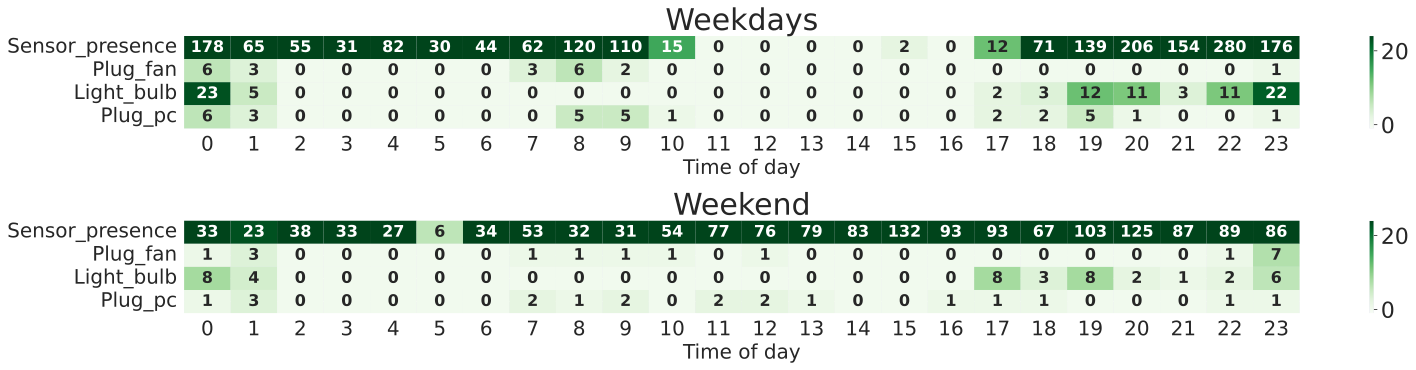

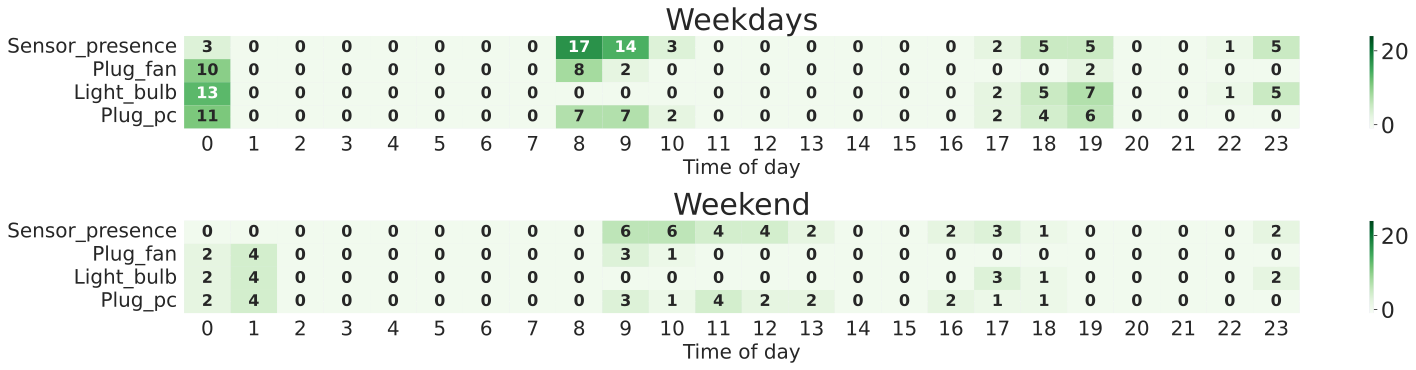

In [12]:
# gráfido de calor com contagem de utilização dos dispositivos


graph_real = device_change_heatmap_Teste(df_real, unique_devices)
graph_real.savefig("grafio_calor_real.pdf", bbox_inches='tight')

graph_gerado = device_change_heatmap_Teste(df_gerado_14d, unique_devices)
graph_gerado.savefig("grafio_calor_gerado.pdf", bbox_inches='tight')

# TEste

In [11]:
df_real = trata_dados_reais('dados.json')
df_real = monta_dataframe_por_dia(df_real).T
df_real['interval'] = df_real['day'].apply(time_interval_teste)
df_real['grupo'] = 'real'


df_gerado_14d = trata_dados_gerados('../dados/original/completo/dados-validacao-14-dias.csv')
df_gerado_14d = monta_dataframe_por_dia(df_gerado_14d).T
df_gerado_14d['interval'] = df_gerado_14d['day'].apply(time_interval_teste)
df_gerado_14d['grupo'] = 'gerado_14_dias'


df_gerado_60d = trata_dados_gerados('../dados/original/completo/dados-validacao-60-dias.csv')
df_gerado_60d = monta_dataframe_por_dia(df_gerado_60d).T
df_gerado_60d['interval'] = df_gerado_60d['day'].apply(time_interval_teste)
df_gerado_60d['grupo'] = 'gerado_60_dias'

Sensor_presence: 1044
Plug_fan: 0
Light_bulb: 5
Plug_pc: 0


In [12]:
def formata_teste_fisher(df:pd.DataFrame, grupo:str):
    formatado = pd.DataFrame()
    unique_devices = ['Sensor_presence', 'Plug_fan', 'Light_bulb', 'Plug_pc']
    for indice, linha in df.iterrows():
        for disp in unique_devices:
            a = pd.DataFrame()
            a = {
                'hora': linha['interval'],
                'contagem': linha[disp],
                'grupo': linha['grupo'],
                'dispositivo': disp
            }
            formatado = pd.concat([formatado, pd.DataFrame([a])], axis=0)
    return formatado


In [13]:
teste_fisher_real = formata_teste_fisher(df_real, 'real')
teste_fisher_14 = formata_teste_fisher(df_gerado_14d, '14_dias')
teste_fisher_60 = formata_teste_fisher(df_gerado_60d, '60_dias')

teste_fisher_concatenado = pd.concat([teste_fisher_real, teste_fisher_14, teste_fisher_60], axis=0, ignore_index=True)
teste_fisher_concatenado.to_excel('teste_fisher_concatenado.xlsx', engine='xlsxwriter')
teste_fisher_concatenado

,hora,contagem,grupo,dispositivo
0,23,4.0,real,Sensor_presence
1,23,6.0,real,Plug_fan
2,23,0.0,real,Light_bulb
3,23,0.0,real,Plug_pc
4,0,7.0,real,Sensor_presence
...,...,...,...,...
8563,21,0.0,gerado_60_dias,Plug_pc
8564,22,2.0,gerado_60_dias,Sensor_presence
8565,22,0.0,gerado_60_dias,Plug_fan
8566,22,2.0,gerado_60_dias,Light_bulb


In [14]:
teste_kruskal_concatenado = pd.concat([df_real, df_gerado_14d, df_gerado_60d], axis=0, ignore_index=True)
teste_kruskal_concatenado.drop(['day'], inplace=True, axis=1)
teste_kruskal_concatenado.rename(columns={'interval': 'hora'}, inplace=True)
teste_kruskal_concatenado.to_excel('teste_kruskal_concatenado.xlsx', engine='xlsxwriter')
teste_kruskal_concatenado


,Sensor_presence,Plug_fan,Light_bulb,Plug_pc,hora,grupo
0,4.0,6.0,0.0,0.0,23,real
1,7.0,0.0,5.0,0.0,0,real
2,9.0,1.0,2.0,1.0,1,real
3,32.0,0.0,0.0,0.0,2,real
4,30.0,0.0,0.0,0.0,3,real
...,...,...,...,...,...,...
2137,1.0,0.0,1.0,1.0,18,gerado_60_dias
2138,0.0,0.0,0.0,0.0,19,gerado_60_dias
2139,0.0,0.0,0.0,0.0,20,gerado_60_dias
2140,0.0,0.0,0.0,0.0,21,gerado_60_dias


In [15]:
teste_kruskal_concatenado_agrupado = teste_kruskal_concatenado.groupby(['hora', 'grupo']).sum()
teste_kruskal_concatenado_agrupado.to_excel('teste_kruskal_concatenado_agrupado.xlsx', engine='xlsxwriter')
teste_kruskal_concatenado_agrupado

Sensor_presence Plug_fan Light_bulb Plug_pc
hora grupo                                                     
0    gerado_14_dias            10.0     12.0       18.0    11.0
     gerado_60_dias            72.0     46.0      114.0    47.0
     real                     211.0      7.0       31.0     7.0
1    gerado_14_dias             9.0      3.0       10.0     3.0
     gerado_60_dias            29.0     22.0       46.0    22.0
...                             ...      ...        ...     ...
22   gerado_60_dias            68.0      0.0       68.0     0.0
     real                     369.0      1.0       13.0     1.0
23   gerado_14_dias            19.0      0.0       19.0     0.0
     gerado_60_dias            97.0      0.0       97.0     0.0
     real                     262.0      8.0       28.0     2.0

[72 rows x 4 columns]

In [16]:
df_real

,day,Sensor_presence,Plug_fan,Light_bulb,Plug_pc,interval,grupo
0,2024-08-03 23:00:00,4.0,6.0,0.0,0.0,23,real
1,2024-08-04 00:00:00,7.0,0.0,5.0,0.0,0,real
2,2024-08-04 01:00:00,9.0,1.0,2.0,1.0,1,real
3,2024-08-04 02:00:00,32.0,0.0,0.0,0.0,2,real
4,2024-08-04 03:00:00,30.0,0.0,0.0,0.0,3,real
...,...,...,...,...,...,...,...
365,2024-08-19 04:00:00,4.0,0.0,0.0,0.0,4,real
366,2024-08-19 05:00:00,0.0,0.0,0.0,0.0,5,real
367,2024-08-19 06:00:00,0.0,0.0,0.0,0.0,6,real
368,2024-08-19 07:00:00,0.0,0.0,0.0,0.0,7,real


# Verificação por tempo de uso

In [17]:
def encoder(data):
    df = data.copy()
    df['message'] = df['message'].apply(lambda msg: 0 if msg == None or "'value': 'none'" in msg or "'value': False" in msg or "'value': 'OFF'" in msg
    else 1 if "'value': 'presence'" in msg or "'value': True" in msg or "'value': 'ON'" in msg else msg)
    return df.query("message == 0 or message == 1")

In [18]:
def transform(data, device_id='devId'):
    df = data.copy()
    start = data['timeStamp'].min().replace(minute=0, second=0, microsecond=0)# + timedelta(minutes=1)
    end = data['timeStamp'].max().replace(microsecond=0)
    timestamps = pd.date_range(start=start, end=end, freq='min')
    devices = df[device_id].unique()

    time_on_list = []
    time_on = {device: 0 for device in devices}
    time_on['timeStamp'] = timestamps[0]

    last_state = {device: 0 for device in devices}

    last_timestamp = start - timedelta(minutes=1)
    for i, current_timestamp in enumerate(timestamps):
        for device in devices:
            time = timedelta(seconds=0)
            registers = df[(df['timeStamp'] <= current_timestamp) & (df['timeStamp'] > last_timestamp)].query(f"{device_id} == '{device}'").reset_index(drop=True)

            if len(registers) > 0:
                if len(registers) == 1:
                    if registers.iloc[0]['message'] == 1:
                        time = current_timestamp - registers.iloc[0]['timeStamp']
                    elif last_state[device] == 1 and registers.iloc[0]['message'] == 0:
                        time = registers.iloc[0]['timeStamp'] - last_timestamp
                    else:
                        time = timedelta(seconds=0)
                else:
                    init = 0
                    if last_state[device] == 1 and registers.iloc[0]['message'] == 0:
                        time += registers.iloc[0]['timeStamp'] - last_timestamp
                        init = 1

                    for index in registers.iloc[init:].index:
                        if registers.iloc[index]['message'] == 1:
                            on = registers.iloc[index]['timeStamp']
                        elif last_state[device] == 1 and registers.iloc[index]['message'] == 0:
                            off = registers.iloc[index]['timeStamp']
                            time += off - on
                        else:
                            time += timedelta(seconds=0)

                    if registers.iloc[-1]['message'] == 1:
                        time += current_timestamp - registers.iloc[-1]['timeStamp']
                last_state[device] = registers.iloc[-1]['message']
            else:
                if last_state[device] == 1:
                    time = timedelta(seconds=60)
                else:
                    time = timedelta(seconds=0)

            # if device == 'ebfe6c248a7dfe6910qdcb':
            #     print(current_timestamp, time)

            time_on[device] = round(time.seconds / 60)
        time_on['timeStamp'] = last_timestamp
        time_on_list.append(time_on.copy())
        last_timestamp = current_timestamp
    return pd.DataFrame(time_on_list)

In [19]:
df_real = trata_dados_reais('dados.json').sort_values('timeStamp', ascending=True).reset_index(drop=True)
df_real['message'] = df_real['message'].apply(lambda x: str(x))

df_gerado_14d = trata_dados_gerados('../dados/original/completo/dados-validacao-14-dias.csv').sort_values('timeStamp', ascending=True).reset_index(drop=True)

df_gerado_60d = trata_dados_gerados('../dados/original/completo/dados-validacao-60-dias.csv').sort_values('timeStamp', ascending=True).reset_index(drop=True)

Sensor_presence: 1044
Plug_fan: 0
Light_bulb: 5
Plug_pc: 0


In [20]:
real_encoded = encoder(df_real)
generated_encoded_14d = encoder(df_gerado_14d)
generated_encoded_60d = encoder(df_gerado_60d)

In [21]:
real_transform = transform(data=real_encoded)
generated_14d_transform = transform(data=generated_encoded_14d)
generated_60d_transform = transform(data=generated_encoded_60d)

KeyboardInterrupt: 

In [77]:
real_transform['hour'] = real_transform['timeStamp'].dt.hour
real_transform['date'] = real_transform['timeStamp'].dt.date

generated_14d_transform['hour'] = generated_14d_transform['timeStamp'].dt.hour
generated_14d_transform['date'] = generated_14d_transform['timeStamp'].dt.date

generated_60d_transform['hour'] = generated_60d_transform['timeStamp'].dt.hour
generated_60d_transform['date'] = generated_60d_transform['timeStamp'].dt.date

In [97]:
devices = list(df_real['devId'].unique())
real_transform = real_transform.groupby(['date', 'hour'])[devices].sum()
real_transform.reset_index(inplace=True)
real_transform['grupo'] = 'real'

devices = list(df_gerado_14d['devId'].unique())
generated_14d_transform = generated_14d_transform.groupby(['date', 'hour'])[devices].sum()
generated_14d_transform.reset_index(inplace=True)
generated_14d_transform['grupo'] = 'gerado_14_dias'

devices = list(df_gerado_60d['devId'].unique())
generated_60d_transform = generated_60d_transform.groupby(['date', 'hour'])[devices].sum()
generated_60d_transform.reset_index(inplace=True)
generated_60d_transform['grupo'] = 'gerado_60_dias'

In [101]:
teste_estatistico_concatenado = pd.concat([real_transform, generated_14d_transform, generated_60d_transform], axis=0, ignore_index=True)
teste_estatistico_concatenado.to_excel('teste_estatistico_concatenado.xlsx', engine='xlsxwriter')

In [102]:
teste_estatistico_concatenado

,date,hour,Plug_fan,Sensor_presence,Light_bulb,abertura,Plug_pc,grupo
0,2024-08-03,22,0,0,0,0.0,0,real
1,2024-08-03,23,0,18,0,0.0,0,real
2,2024-08-04,0,0,42,1,0.0,0,real
3,2024-08-04,1,42,45,5,0.0,0,real
4,2024-08-04,2,60,60,0,0.0,0,real
...,...,...,...,...,...,...,...,...
2140,2024-09-16,18,0,43,43,NaN,43,gerado_60_dias
2141,2024-09-16,19,0,60,60,NaN,60,gerado_60_dias
2142,2024-09-16,20,0,60,60,NaN,60,gerado_60_dias
2143,2024-09-16,21,0,60,60,NaN,60,gerado_60_dias
